tmax = 111.89999999996617 c
max = 14.4306207953
t0.8 = 211.54999999987555 c
signal0.8 = 11.460637695299999


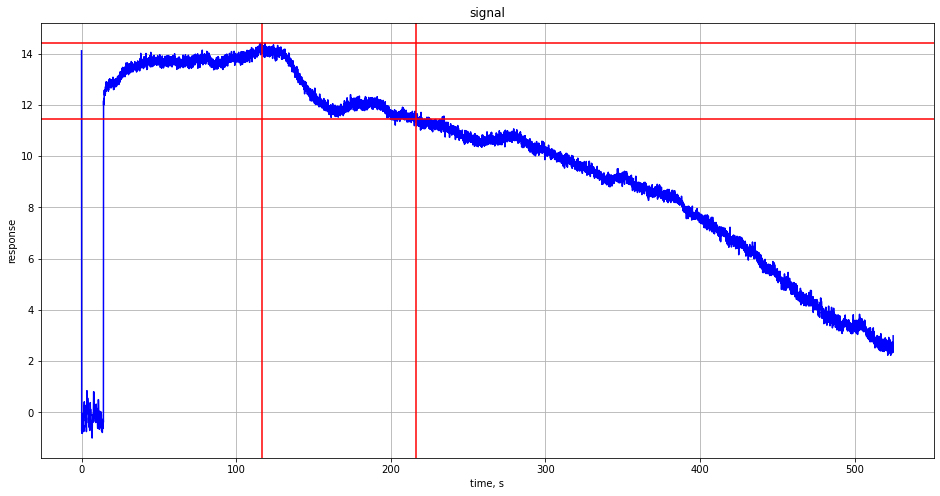

In [11]:
#v. 20241112.1
import matplotlib.pyplot as plt
import numpy as np


input_dir = "./data/pepperberg/"
output_dir = './output/pepperberg/'
filename = "file 26.asc"
fs = 200            # частота дискретизации, Гц
divider = 10        # во сколько раз проредить сигнал (уменьшить частоту дискретизации)
sign = -1           # полярность {1:'стимул вверх', -1:'стимул вниз'}
left_border = 0     # левая граница участка, по которому вычисляется средняя для вычета нулевой линии, с
right_border = 5    # правая граница участка, по которому вычисляется средняя для вычета нулевой линии, с
prefix = 5          # момент подачи стимула, с
level = 0.8         # уровень от максимума сигнала; программа ищет время, которое соответствует этому уровню

time = 0
t = []
signal = []
with open(input_dir + filename, 'r', encoding='utf-8') as file:
    for line in file:
        line = line.strip()
        try:
            line = float('0' if line == '.' else line)
        except ValueError:
            continue
        t.append(time)
        signal.append(sign * line)
        time += 1 / fs

fs = fs // divider
t = np.array(t[::divider])
signal = np.array(signal[::divider])
signal -= np.mean(signal[left_border * fs:right_border * fs]) # вычитание нулевой линии
maxi = np.argmax(signal[prefix * fs:]) + prefix * fs
left = maxi
right = len(t) - 1
while left <= right:
    mid = left + (right - left) // 2
    if signal[mid] <= level * signal[maxi]:
        right = mid - 1
    else:
        left = mid + 1
leveli = left
print(f'tmax = {t[maxi] - prefix} c')   # по заданию выводим время за вычетом префикса сигнала
print(f'max = {signal[maxi]}')
print(f't{level} = {t[leveli] - prefix} c') # по заданию выводим время за вычетом префикса сигнала
print(f'signal{level} = {signal[leveli]}')


fig, ax = plt.subplots()
ax.plot(t, signal, 'b')
ax.axvline(x=t[maxi], color='r')
ax.axhline(y=signal[maxi], color='r')
ax.axvline(x=t[leveli], color='r')
ax.axhline(y=signal[leveli], color='r')
fig.set_figwidth(16)
fig.set_figheight(8)
ax.set_title(f'signal')
ax.set_xlabel('time, s')
ax.set_ylabel('response')
ax.grid()

In [12]:
with open(f'{output_dir}{filename[:-4]}_fs{fs}.txt', 'w', encoding='utf-8') as file:
    for value in signal:
        file.write(f'{value}\n')